In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import sys

sys.path.append("..")

import os
import optuna
import torch
import wandb
import gc
import pandas as pd

from src.training import train_model
from src.models.model_unet import UNet
from src.dataprocess.torch_dataset_SNSD import DenoisingSpectrogramDataset
from torch.utils.data import DataLoader
import librosa
import matplotlib.pyplot as plt
import numpy as np
from src import utils
import IPython.display as ipd

# Path to Dataset
DATA_DIR = "/media/gabriel/500 BKP/datasets/SNSD-DataSet/raw/train/CleanSpeech"

In [43]:
WIN_LENGTH = 512
N_FFT = 512
HOP_LENGTH = 128
SAMPLE_RATE = 16000
TARGET_FRAMES = 1024

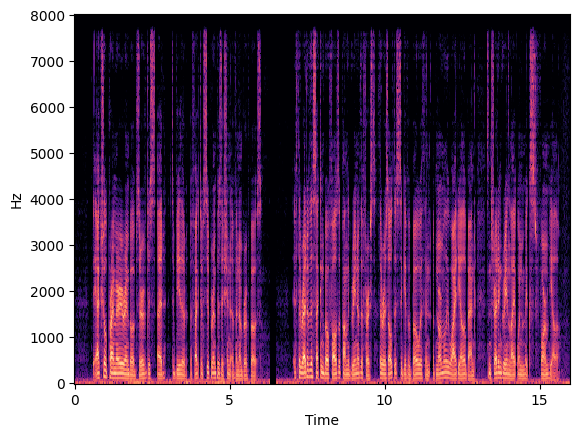

In [50]:
clean_path = os.path.join(DATA_DIR, 'clnsp5.wav')
clean_mag = utils.compute_mag_spectrogram(clean_path, SAMPLE_RATE, N_FFT, HOP_LENGTH, WIN_LENGTH)
clean_mag_db = librosa.amplitude_to_db(np.maximum(clean_mag, 1e-5), ref=np.max)

ipd.display(ipd.Audio(clean_path, rate=SAMPLE_RATE))
librosa.display.specshow(clean_mag_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, y_axis='linear', x_axis='time')

reconstructed = librosa.griffinlim(clean_mag, n_iter=64, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
ipd.display(ipd.Audio(reconstructed, rate=SAMPLE_RATE))

In [53]:
np.array([[1, 0, 1], [0, 1, 1], [1, 0, 1]]), np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

array([[ 8, 10, 12],
       [11, 13, 15],
       [ 8, 10, 12]])